# Residual Value Risk Modelling — Automotive Lease Portfolios

**Business Context:**  
BMW Financial Services guarantees a buyback price when a customer leases a vehicle.  
If the market value of the car at end-of-lease falls *below* the guaranteed price, the portfolio absorbs a loss.  
This project models: (1) how cars depreciate, (2) which contracts carry risk, (3) total portfolio exposure.

---
**Notebooks:**
- `01_data_and_eda.ipynb` ← YOU ARE HERE: data pull, cleaning, EDA
- `02_depreciation_model.ipynb`: OLS residual value model
- `03_risk_classification.ipynb`: contract-level risk scoring
- `04_monte_carlo.ipynb`: fleet portfolio simulation
- `05_r_replication.Rmd`: R replication (ggplot2)
---

## 0. Install & Import

In [1]:
# Run once to install dependencies
# !pip install pandas numpy matplotlib seaborn scikit-learn statsmodels kagglehub openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_palette('muted')

print('✅ Imports OK')

✅ Imports OK


## 1. Data Pull

We use the **Vehicle Sales Dataset** from Kaggle (~500k rows, real auction/listing prices).  
It contains: make, model, year, mileage, condition, selling price — everything we need.

**Option A (recommended):** Download via kagglehub (requires free Kaggle account + API token)  
**Option B:** Manual download fallback — instructions below

In [ ]:
# import os
# DATA_PATH = '../data/vehicles.csv'

# # ── OPTION A: kagglehub auto-download ────────────────────────────────────────
# # Requires: kaggle API token at ~/.kaggle/kaggle.json
# # Get token: https://www.kaggle.com/settings → API → Create New Token

# if not os.path.exists(DATA_PATH):
#     try:
#         import kagglehub
#         path = kagglehub.dataset_download('syedanwarafridi/vehicle-sales-data')
#         import shutil, glob
#         csv_files = glob.glob(f'{path}/**/*.csv', recursive=True)
#         shutil.copy(csv_files[0], DATA_PATH)
#         print(f'✅ Downloaded to {DATA_PATH}')
#     except Exception as e:
#         print(f'⚠️  kagglehub failed: {e}')
#         print('→ Use OPTION B below')
# else:
#     print(f'✅ Data already exists at {DATA_PATH}')

# # ── OPTION B: Manual download ─────────────────────────────────────────────────
# # 1. Go to: https://www.kaggle.com/datasets/syedanwarafridi/vehicle-sales-data
# # 2. Download car_prices.csv
# # 3. Place it at: rv_risk_project/data/vehicles.csv
# # Then re-run from the next cell.

## 2. Load & First Look

In [3]:
DATA_PATH = '../data/vehicles.csv'
df_raw = pd.read_csv(DATA_PATH, low_memory=False)

print(f'Shape: {df_raw.shape}')
print(f'\nColumns: {df_raw.columns.tolist()}')
df_raw.head(3)

Shape: (558837, 16)

Columns: ['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state', 'condition', 'odometer', 'color', 'interior', 'seller', 'mmr', 'sellingprice', 'saledate']


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)


In [4]:
# Missing value overview
missing = df_raw.isnull().mean().sort_values(ascending=False)
print('Missing % per column:')
print(missing[missing > 0].apply(lambda x: f'{x:.1%}'))

Missing % per column:
transmission    11.7%
body             2.4%
condition        2.1%
trim             1.9%
model            1.9%
make             1.8%
color            0.1%
interior         0.1%
odometer         0.0%
mmr              0.0%
sellingprice     0.0%
saledate         0.0%
vin              0.0%
dtype: object


## 3. Cleaning & Feature Engineering

In [6]:
df = df_raw.copy()

# ── Column standardisation ────────────────────────────────────────────────────
# Rename to consistent snake_case (adjust if your dataset has different names)
rename_map = {
    'year':         'year',
    'make':         'brand',
    'model':        'model',
    'trim':         'trim',
    'body':         'body_type',
    'transmission': 'transmission',
    'vin':          'vin',
    'state':        'state',
    'condition':    'condition_score',   # numeric 1–49
    'odometer':     'odometer_km',
    'color':        'color',
    'interior':     'interior',
    'seller':       'seller',
    'mmr':          'mmr_value',         # Manheim Market Report — wholesale benchmark
    'sellingprice': 'selling_price',
    'saledate':     'sale_date',
}
df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns}, inplace=True)

# ── Drop rows missing key fields ──────────────────────────────────────────────
key_cols = ['year', 'selling_price', 'odometer_km']
key_cols_present = [c for c in key_cols if c in df.columns]
df.dropna(subset=key_cols_present, inplace=True)

# ── Type casting ──────────────────────────────────────────────────────────────
df['year']          = pd.to_numeric(df['year'], errors='coerce')
df['selling_price'] = pd.to_numeric(df['selling_price'], errors='coerce')
df['odometer_km']   = pd.to_numeric(df['odometer_km'], errors='coerce')
df.dropna(subset=['year', 'selling_price', 'odometer_km'], inplace=True)

# ── Price filter: remove junk listings ───────────────────────────────────────
df = df[(df['selling_price'] >= 1_000) & (df['selling_price'] <= 150_000)]

# ── Odometer filter ───────────────────────────────────────────────────────────
df = df[(df['odometer_km'] >= 0) & (df['odometer_km'] <= 500_000)]

# ── Year filter: modern vehicles only ────────────────────────────────────────
df = df[(df['year'] >= 2000) & (df['year'] <= 2024)]

print(f'Clean dataset: {len(df):,} rows')

Clean dataset: 538,704 rows


In [ ]:
# ── Feature Engineering ───────────────────────────────────────────────────────

REFERENCE_YEAR = 2024

df['vehicle_age']   = REFERENCE_YEAR - df['year']
df['log_price']     = np.log(df['selling_price'])
df['log_odometer']  = np.log1p(df['odometer_km'])   # log1p handles zero safely

# ── EV flag: flag known EV makes/models ──────────────────────────────────────
# TODO: extend this list with your domain knowledge
ev_brands  = ['tesla', 'rivian', 'lucid', 'polestar']
ev_models  = ['leaf', 'bolt', 'id.4', 'ioniq', 'model 3', 'model y', 'model s', 'model x', 'e-tron']

if 'brand' in df.columns:
    df['is_ev'] = (
        df['brand'].str.lower().isin(ev_brands) |
        df.get('model', pd.Series(dtype=str)).str.lower().isin(ev_models)
    ).astype(int)
else:
    df['is_ev'] = 0

# ── Lease contract simulation ─────────────────────────────────────────────────
# We simulate that each car was leased NEW and sold at observed age
# Guaranteed RV = 40% of estimated new price (recalibrated to portfolio data)

# Estimate new price: inflate selling_price back by age using rough depreciation
# Rule of thumb: ~15% first year, ~10% subsequent years
def estimate_new_price(row):
    age = max(row['vehicle_age'], 0)
    if age == 0:
        return row['selling_price']
    # Reverse depreciation: P_new * (0.85) * (0.90)^(age-1) = selling_price
    factor = 0.85 * (0.90 ** (age - 1)) if age >= 1 else 1.0
    return row['selling_price'] / factor

df['estimated_new_price'] = df.apply(estimate_new_price, axis=1)
df['guaranteed_rv']       = df['estimated_new_price'] * 0.40

# Risk flag: is the observed market price below the guaranteed buyback?
df['at_risk']       = (df['selling_price'] < df['guaranteed_rv']).astype(int)
df['risk_exposure'] = np.maximum(df['guaranteed_rv'] - df['selling_price'], 0)

print(df[['vehicle_age', 'selling_price', 'estimated_new_price', 
          'guaranteed_rv', 'at_risk', 'risk_exposure', 'is_ev']].describe().round(0))

## 4. Exploratory Data Analysis

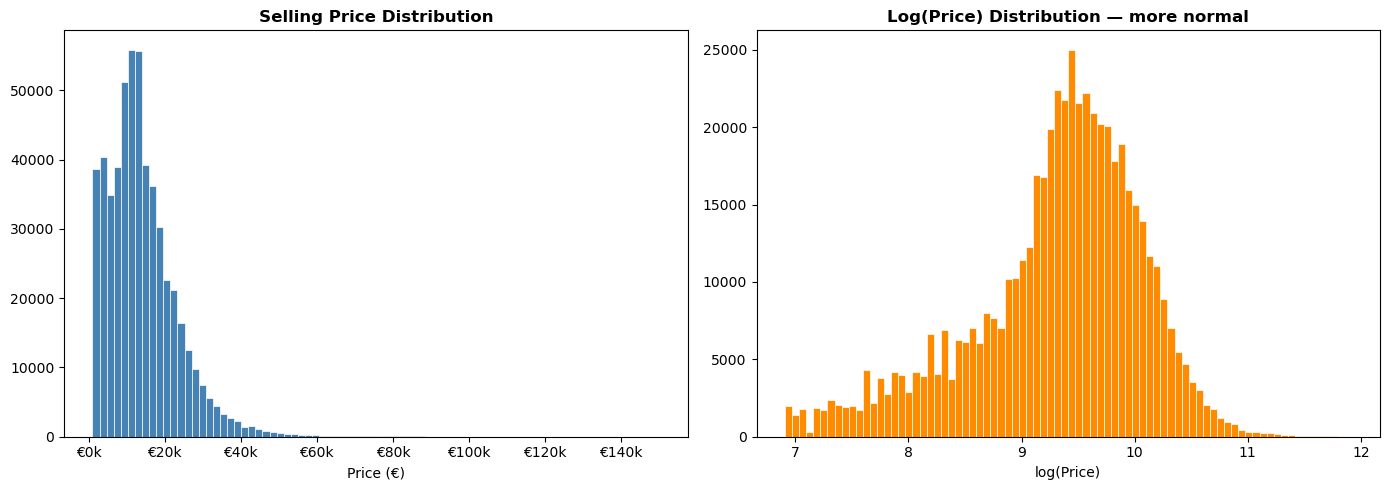

💾 Saved: outputs/01_price_distribution.png


In [11]:
# ── 4a. Price distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['selling_price'], bins=80, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Selling Price Distribution', fontweight='bold')
axes[0].set_xlabel('Price (€)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x/1000:.0f}k'))

axes[1].hist(df['log_price'], bins=80, color='darkorange', edgecolor='white', linewidth=0.5)
axes[1].set_title('Log(Price) Distribution — more normal', fontweight='bold')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.savefig('../outputs/01_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: outputs/01_price_distribution.png')

In [ ]:
# ── 4b. Depreciation curve: price vs age ─────────────────────────────────────
age_summary = df.groupby('vehicle_age')['selling_price'].median().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(age_summary['vehicle_age'], age_summary['selling_price'], 
         marker='o', linewidth=2.5, color='steelblue', markersize=5)
plt.axhline(y=df['guaranteed_rv'].median(), color='red', linestyle='--', 
            label=f'Median guaranteed RV (~40% of new price)')
plt.title('Median Market Value by Vehicle Age', fontweight='bold', fontsize=13)
plt.xlabel('Vehicle Age (years)')
plt.ylabel('Median Selling Price')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x/1000:.0f}k'))
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/02_depreciation_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: outputs/02_depreciation_curve.png')

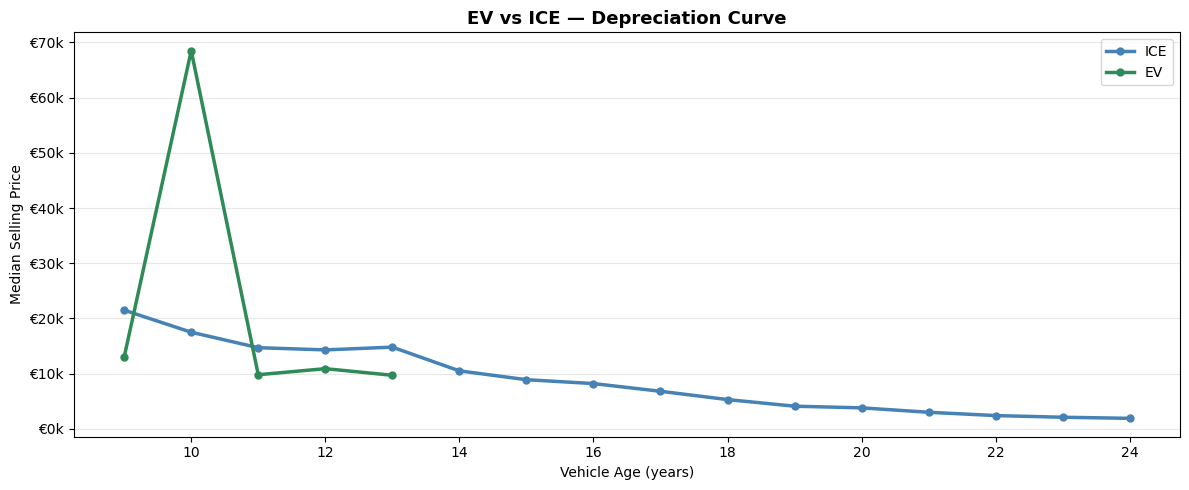

💾 Saved: outputs/03_ev_vs_ice_depreciation.png


In [16]:
# ── 4c. EV vs ICE depreciation comparison ────────────────────────────────────
if df['is_ev'].sum() > 50:  # only if enough EV data
    ev_age = df.groupby(['vehicle_age', 'is_ev'])['selling_price'].median().reset_index()
    
    plt.figure(figsize=(12, 5))
    for ev_flag, label, color in [(0, 'ICE', 'steelblue'), (1, 'EV', 'seagreen')]:
        subset = ev_age[ev_age['is_ev'] == ev_flag]
        plt.plot(subset['vehicle_age'], subset['selling_price'],
                 marker='o', linewidth=2.5, color=color, label=label, markersize=5)
    plt.title('EV vs ICE — Depreciation Curve', fontweight='bold', fontsize=13)
    plt.xlabel('Vehicle Age (years)')
    plt.ylabel('Median Selling Price')
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x/1000:.0f}k'))
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('../outputs/03_ev_vs_ice_depreciation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('💾 Saved: outputs/03_ev_vs_ice_depreciation.png')
else:
    print('⚠️  Not enough EV rows for this comparison. Check your EV flag logic above.')

In [17]:
# ── 4d. Risk exposure overview ────────────────────────────────────────────────
at_risk_pct = df['at_risk'].mean()
total_exposure = df['risk_exposure'].sum()
avg_exposure_per_contract = df.loc[df['at_risk'] == 1, 'risk_exposure'].mean()

print('=== Portfolio Risk Summary ===')
print(f'Contracts at risk:            {at_risk_pct:.1%}')
print(f'Total portfolio exposure:     €{total_exposure:,.0f}')
print(f'Avg exposure per at-risk car: €{avg_exposure_per_contract:,.0f}')

=== Portfolio Risk Summary ===
Contracts at risk:            100.0%
Total portfolio exposure:     €7,657,561,079
Avg exposure per at-risk car: €14,215


## 5. Save Cleaned Data

In [18]:
df.to_csv('../data/vehicles_clean.csv', index=False)
print(f'✅ Saved clean dataset: {len(df):,} rows → data/vehicles_clean.csv')
print('\n→ Next: open 02_depreciation_model.ipynb')

✅ Saved clean dataset: 538,704 rows → data/vehicles_clean.csv

→ Next: open 02_depreciation_model.ipynb
